There are two things that I would still like to explore. 1) extension to 2D of equivariance and mass conservation 2) automatic training data enrichment. I start with the extension to 2D. 

For mass conservation in 1D we did a final convolution with the filter [0, -1, 1], this had the effect of predicting changes in u for each cell. We do something similar for 2D. We start with 2 channels for u and v, we then convolve through a couple of hidden layers untill we convolve back to 4 channels. These 4 channels are then interpreted as u flux in x direction, u flux in y direction, v flux in x direction, v flux in y direction. By convolving the x direction fluxes with [0 0 0; 0 -1 1; 0 0 0] and the y direction fluxes with [0 1 0; 0 -1 0; 0 0 0] we again get a prediction for the update in the u and v field, conserving mass.

We see that this technique again works quite well for the 2D case. Stability and accuracy plots over a large amount of initial conditions, model sizes, seeds, and training data would be nice to have. The problem that I am having, is that these models take much much longer to train and test, I could try to produce some nice plots for the report, but not with as many datapoints as I had for the 1D case.

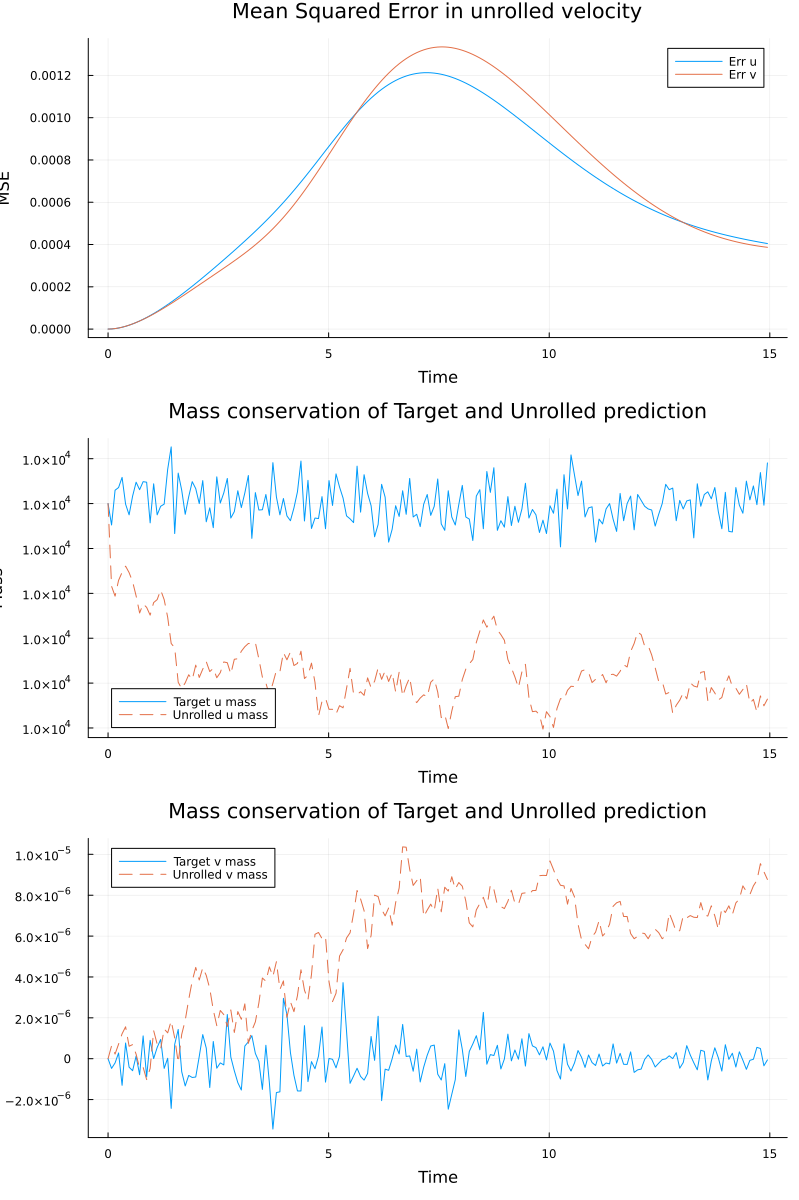

In [1]:
display("image/png", read("../media/2d_mass_conserve.png"))

We can now also look at equivariance, which is much more challenging. In theory there is a continuous symmetry according to rotating the full wave over the z axis. I chose to limit the equivariance to 90 degrees rotations, as this means that I dont have to do a lot of interpolations and projections. The method works as follows. Lift the input data to rotations by 0, 90, 180, 270 degrees. Because we work with vector data we might also need to swap or negate the u and v fields for example, say that we want to do a counter-clockwise rotation of 90 degrees. We start with fields (u, v) the rotate the fields to get (rot(u), rot(v)), then correct for vector data to get (-rot(v), rot(u)), or for 180 degrees (u, v) -> (-rot(u), -rot(v)). We again run all rotated versions through the network and then rotate them back, and then average. 

Here I show two different models, first, a mass conserving 2D model, and second, a mass conserving equivariant 2D model. We do timestepping on a given previous timestep, as well as, a transformed version of the privous timestep, in that case we also do the inverse transformation on the predicted timestep. The difference between these two outputs gives insight into the equivariance qualities of the network. We see that the equivariant network has almost no difference between the two outputs, with the few points of difference presumable being contributed to floating point error. Again we do not get this property for free, we are scaling computations by the size of symmetry group, in this case 4, which causes a roughly 4x training time. 106s vs 352s. Again big  analyses of the accuracy and stability are still desired, but computationally prohibitive.

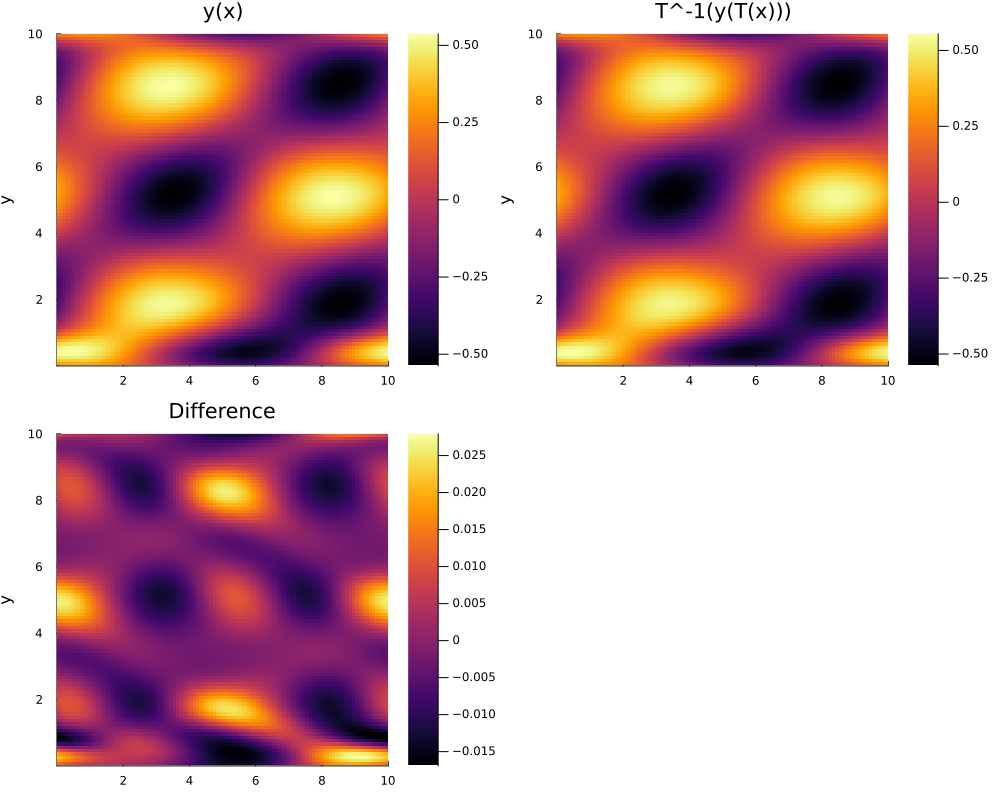

In [3]:
display("image/png", read("../media/noequi_2d.png"))

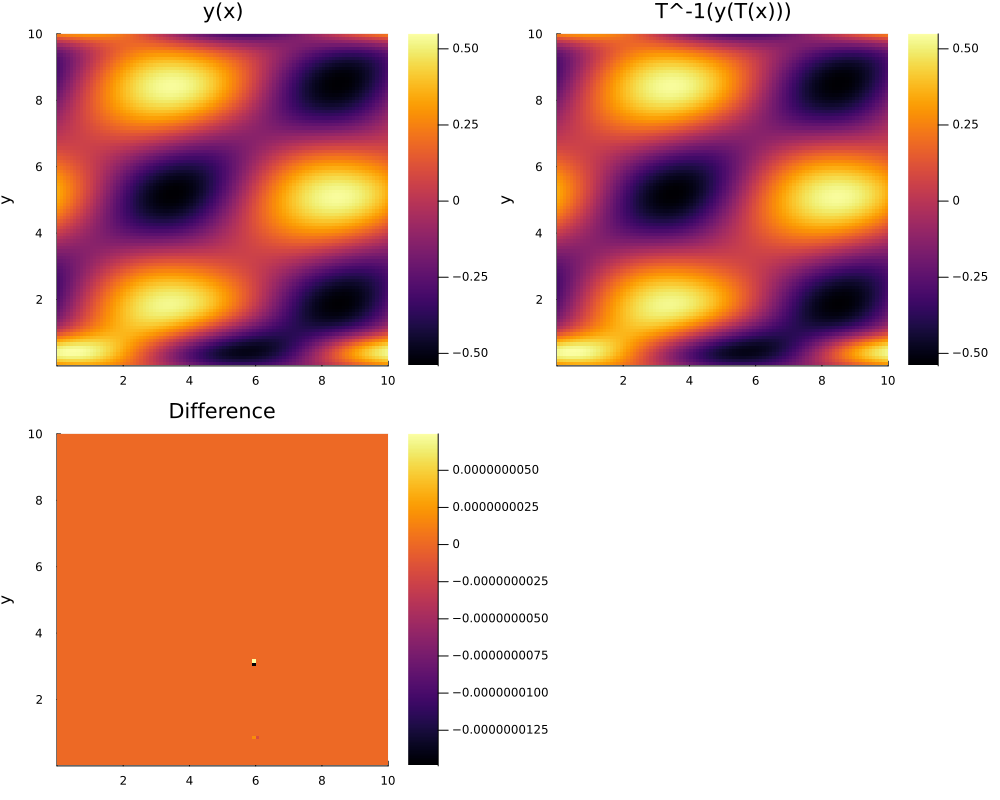

In [4]:
display("image/png", read("../media/equi_2d.png"))